In [43]:
%matplotlib inline

from collections.abc import Callable

import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

In [44]:
# Objective Function & Gradient Descent

def objective(
    x: torch.Tensor,
) -> torch.Tensor:
    return x.pow(2)

def objective_gradient(
    x: torch.Tensor,
) -> torch.Tensor:
    return 2 * x

def gradient_descent(
    learning_rate: float,
    gradient: Callable[
        [torch.Tensor],
        torch.Tensor,
    ],
    num_steps: int = 10,
) -> list[float]:
    x = torch.tensor(
        10.0
    )
    
    results = [
        x.item()
    ]
    
    for _ in range(num_steps):
        x = (
            x - learning_rate * gradient(x)
        )
        
        results.append(
            x.item()
        )
        
    print(
        f"[Gradient Descent] "
        f"step {num_steps}, "
        f"x: {x.item():f}"
    )  

    return results

[Gradient Descent] step 10, x: 0.060466


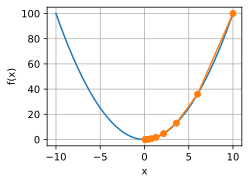

In [45]:
# Optimization Trace

def show_trace(
    results: list[float],
    function: Callable[
        [torch.Tensor],
        torch.Tensor,
    ],
) -> None:
    results_tensor = torch.tensor(
        results
    )
    
    bound = results_tensor.abs().max().item()
    
    x_line = torch.arange(
        -bound,
        bound,
        1e-2,
    )
    
    d2l.plot(
        [
            x_line,
            results_tensor,
        ],
        [
            function(x_line),
            function(results_tensor),
        ],
        xlabel="x",
        ylabel="f(x)",
        fmts=[
            "-",
            "-o",
        ],
    )
    
results = gradient_descent(
    learning_rate=0.2,
    gradient=objective_gradient,
)

show_trace(
    results,
    objective,
)

[Gradient Descent] step 10, x: 3.486785


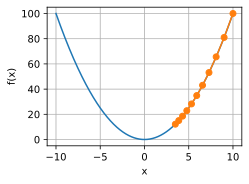

In [46]:
# 너무 작은 learning rate: 수렴 속도가 낮음

small_learning_rate_results = (
    gradient_descent(
        learning_rate=0.05,
        gradient=objective_gradient,
    )
)

show_trace(
    small_learning_rate_results,
    objective,
)

[Gradient Descent] step 10, x: 61.917389


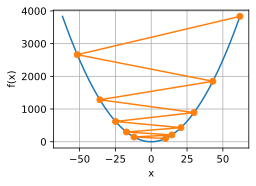

In [47]:
# 지나치게 큰 learning rate: 발산하거나 진동함

large_learning_rate_results = (
    gradient_descent(
        learning_rate=1.1,
        gradient=objective_gradient,
    )
)

show_trace(
    large_learning_rate_results,
    objective,
)

[Gradient Descent] step 10, x: 5.290471


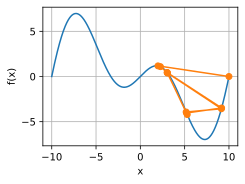

In [55]:
# Nonconvex Function의 Local Minimum

c = torch.tensor(
    0.15 * np.pi
)

def nonconvex_objective(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        x * torch.cos(c * x)
    )
    
def nonconvex_gradient(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        torch.cos(c * x) - c * x * torch.sin(c * x)
    )
    
local_minimum_results = (
    gradient_descent(
        learning_rate=1.7,
        gradient=nonconvex_gradient,
    )
)

show_trace(
    local_minimum_results,
    nonconvex_objective
)